# Figures 3.3-2 and 3.3-3 &mdash; methane and nitrogen, from the Peng&ndash;Robinson equation

Figure 3.3-2 is a **pressure&ndash;enthalpy chart for methane** and Figure 3.3-3 is the same
chart for **nitrogen**. This notebook draws both of them from the **Peng&ndash;Robinson
equation of state** &mdash; the equation of Chapter 6 &mdash; and nothing else.

That is worth saying plainly, because it is unusual. A property chart normally arrives from
outside the book, measured and correlated by somebody else, and you read it on trust. These two
you can rebuild. Every curve on them comes from three inputs:

| | |
|---|---|
| $T_c$, $P_c$, $\omega$ | **Table 6.6-1**, three numbers per fluid |
| $C_P^{*}(T)$ | **Appendix A.II**, four coefficients |
| the equation itself | **Eq. 6.4-2**, plus the departure functions of &sect;6.4 |

The book already does this once, for oxygen: Illustration 6.4-1 builds the charts,
Illustration 7.5-1 adds the vapor pressure and the two coexisting phases, and Illustration 7.5-2
completes them &mdash; Table 7.5-2 is 208 of these numbers in print. What is new here is only the
drawing.

**What this notebook does**

1. settles methane's ideal-gas heat capacity, which Appendix A.II's printed row gets badly
   wrong at these temperatures &mdash; and which everything else rests on;
2. checks the equation of state against the book's own vapor-pressure constants before drawing
   anything with it;
3. builds the five families of curves a $P$&ndash;$\hat H$ chart is made of;
4. draws both charts;
5. works **Illustration 6.5-1** on the nitrogen chart, which is where the text reads it.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst<br>
August 2026

In [1]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when the thermo package is already alongside this notebook (the normal
# case: you cloned the repository and are running from code/ch3/). In Colab
# there is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    # rm -rf first: git clone REFUSES an existing directory, and under `!` that
    # failure is silent -- a half-finished earlier clone would otherwise leave an
    # empty thermo/ and surface as a baffling ImportError further down.
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
else:
    sys.path.insert(0, '..')
DATA = '../data' if os.path.isdir('../data') else 'data'
# ---------------------------------------------------------------------------


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.constants import R

from thermo import APPENDIX_A2_CP_CRYO, TABLE_6_6_1
from thermo.charts import use_book_style
from thermo.ph_chart import (ChartFluid, dome, isentrope, isochore, isotherm,
                             ph_chart, quality, PREF, TREF)

use_book_style()          # Computer Modern, with real TeX if it is installed

True

## 1. Methane's ideal-gas heat capacity, and why the printed row will not do

Every enthalpy on these charts is an ideal-gas enthalpy plus a departure function, so
$C_P^{*}(T)$ sets the whole scale. For nitrogen the book already has what is needed. For
methane it does not, and the gap is the largest of its kind in the book.

Appendix A.II gives methane as $19.875 + 5.021\times10^{-2}\,T + 1.268\times10^{-5}\,T^2 -
11.004\times10^{-9}\,T^3$, **valid 273&ndash;1500 K**, and inside that range it is excellent:
35.68 J/(mol K) at 298 K. The methane chart starts at 111 K. Extrapolated down there, the same
row returns **25.0 J/(mol K)** &mdash; and that number is impossible.

**Why impossible?** A methane molecule has three ways to store energy: moving (translation),
tumbling (rotation), and its atoms vibrating against one another. At low temperature the
vibrations are frozen out &mdash; there is not enough thermal energy to excite them &mdash; and
only the first two survive. For a *nonlinear* molecule that gives

$$ C_P^{*} \;\longrightarrow\; \underbrace{\tfrac32 R}_{\text{translation}}
   + \underbrace{\tfrac32 R}_{\text{rotation}} + \underbrace{R}_{PV}
   \;=\; 4R \;=\; 33.26 \ \mathrm{J/(mol\ K)} $$

as a floor, not a value to be fitted. A.II's extrapolation goes 25 % *below* the floor.

So we compute it instead. Adding the vibrations back is one standard expression &mdash; each
normal mode contributes an Einstein term:

$$ C_P^{*}(T) = 4R + R\sum_i g_i \frac{u_i^2 e^{u_i}}{(e^{u_i}-1)^2},
   \qquad u_i = \frac{hc\tilde\nu_i}{k_BT} $$

with methane's nine modes at $\tilde\nu$ = 2917 (&times;1), 1534 (&times;2), 3019 (&times;3) and
1306 (&times;3) cm$^{-1}$. **The next cell checks that against NIST-JANAF over the range where
JANAF exists**, which is the whole basis for trusting it below that range.

In [3]:
from scipy import constants as C

# CH4's nine normal modes (3N - 6): wavenumber in cm^-1, and degeneracy.
CH4_MODES = [(2917.0, 1), (1534.0, 2), (3019.0, 3), (1306.0, 3)]


def cp_methane_statmech(T):
    """Ideal-gas Cp* of methane, J/(mol K), from its vibrational spectrum."""
    T = np.asarray(T, float)
    vib = np.zeros_like(T)
    for nu, g in CH4_MODES:
        u = C.h*C.c*100*nu/(C.k*T)
        vib += g*u**2*np.exp(u)/(np.exp(u) - 1)**2
    return 4*R + R*vib          # 4R = translation + rotation + R, the low-T floor


def cp_methane_janaf(T):
    """NIST-JANAF Shomate fit, 298-1300 K. Chase, NIST-JANAF Thermochemical Tables,
    4th ed., J. Phys. Chem. Ref. Data Monograph 9 (1998); webbook.nist.gov C74828."""
    A, B, Cc, D, E = -0.703029, 108.4773, -42.52157, 5.862788, 0.678565
    t = np.asarray(T, float)/1000
    return A + B*t + Cc*t**2 + D*t**3 + E/t**2


def cp_A2_printed(T):
    """Appendix A.II's methane row as printed, valid 273-1500 K."""
    T = np.asarray(T, float)
    return 19.875 + 5.021e-2*T + 1.268e-5*T**2 - 11.004e-9*T**3


T = np.array([298.15, 400, 500, 700, 1000, 1300])
print("where JANAF exists -- this is the check:")
print(f"{'T (K)':>8}{'derived':>10}{'JANAF':>9}{'diff':>8}")
for t in T:
    print(f"{t:8.1f}{cp_methane_statmech(t):10.3f}{cp_methane_janaf(t):9.3f}"
          f"{cp_methane_statmech(t)-cp_methane_janaf(t):+8.3f}")
print(f"\nworst disagreement over 298-1300 K: "
      f"{np.abs(cp_methane_statmech(np.linspace(298,1300,400)) - cp_methane_janaf(np.linspace(298,1300,400))).max():.3f}"
      " J/(mol K)\n")
print("below JANAF's range -- where this chart lives:")
print(f"{'T (K)':>8}{'derived':>10}{'A.II':>9}{'A.II err':>10}")
for t in (100, 120, 150, 200, 250):
    d, a = float(cp_methane_statmech(t)), float(cp_A2_printed(t))
    print(f"{t:8.1f}{d:10.3f}{a:9.3f}{100*(a-d)/d:9.1f}%")
print(f"\nthe floor, 4R = {4*R:.3f} J/(mol K)")

where JANAF exists -- this is the check:
   T (K)   derived    JANAF    diff
   298.1    35.640   35.648  -0.009
   400.0    40.500   40.501  -0.001
   500.0    46.342   46.352  -0.010
   700.0    57.794   57.791  +0.002
  1000.0    71.793   71.794  -0.001
  1300.0    81.742   81.738  +0.004

worst disagreement over 298-1300 K: 0.034 J/(mol K)

below JANAF's range -- where this chart lives:
   T (K)   derived     A.II  A.II err
   100.0    33.258   25.012    -24.8%
   120.0    33.259   26.064    -21.6%
   150.0    33.274   27.655    -16.9%
   200.0    33.474   30.336     -9.4%
   250.0    34.216   33.048     -3.4%

the floor, 4R = 33.258 J/(mol K)


The derived curve reproduces JANAF to **&plusmn;0.03 J/(mol K)** &mdash; far better than any use
here needs, and enough to say that the same expression continued below 298 K is physics rather
than an extrapolation. It arrives at 33.26 at 100 K, which is $4R$ to three decimals.

The printed row, meanwhile, is **25 % low at 100 K**. Integrated across the span this chart
covers, that is **&minus;635 J/mol in $\underline H$ and &minus;4.5 J/(mol K) in $\underline S$**
&mdash; 8 % of methane's entire heat of vaporization, which would visibly misplace every isotherm.

So the 6e adds a **cryogenic-range methane row to Appendix A.II**, in the appendix's own cubic
form and its own idiom &mdash; A.II already splits gases into temperature ranges, and the range
column does the work. The cell below is the fit, and it is the provenance for the numbers in
`thermo.APPENDIX_A2_CP_CRYO["methane"]`: if you doubt a coefficient, run this.

In [4]:
from thermo import APPENDIX_A2_CP_CRYO

FIT_RANGE = (100, 500)      # K
Tf = np.linspace(*FIT_RANGE, 2000)
coef = np.polyfit(Tf, cp_methane_statmech(Tf), 3)[::-1]

# Appendix A.II prints a, b x 10^2, c x 10^5, d x 10^9 -- and to three decimals. Round
# to what the page can print, so a reader who types the printed row in here gets these
# same curves back.
printed = (round(coef[0], 3), round(coef[1]*1e2, 3)/1e2,
           round(coef[2]*1e5, 3)/1e5, round(coef[3]*1e9, 3)/1e9)
print("Appendix A.II form:  a = %.3f   b = %+.3f   c = %+.3f   d = %+.3f   (x1, x1e2, x1e5, x1e9)"
      % (printed[0], printed[1]*1e2, printed[2]*1e5, printed[3]*1e9))
print("in thermo         : ", APPENDIX_A2_CP_CRYO["methane"])
assert np.allclose(printed, APPENDIX_A2_CP_CRYO["methane"], rtol=1e-9), \
    "the fit no longer matches the tabulated row"

cp_fit = lambda T: sum(printed[i]*np.asarray(T, float)**i for i in range(4))
Tc_span = np.linspace(100, 400, 3000)                  # the chart's own span
for label, cp in (("cryogenic row", cp_fit), ("A.II as printed", cp_A2_printed)):
    e = cp(Tc_span) - cp_methane_statmech(Tc_span)
    print(f"  {label:16s} max |dCp*| = {np.abs(e).max():6.3f}   "
          f"dH = {np.trapezoid(e, Tc_span):+8.1f} J/mol   "
          f"dS = {np.trapezoid(e/Tc_span, Tc_span):+7.3f} J/(mol K)")

Appendix A.II form:  a = 37.097   b = -5.282   c = +18.976   d = -92.669   (x1, x1e2, x1e5, x1e9)
in thermo         :  (37.097, -0.05282, 0.00018976, -9.2669e-08)
  cryogenic row    max |dCp*| =  0.362   dH =     +2.2 J/mol   dS =  +0.010 J/(mol K)
  A.II as printed  max |dCp*| =  8.246   dH =   -635.2 J/mol   dS =  -4.521 J/(mol K)


## 2. Does the equation of state earn the chart? Check it before drawing

Peng&ndash;Robinson is a cubic, and cubics are not exact. Before drawing 300 curves with one it
is worth asking what it gets right, against something independent.

`code/data/pure_property.csv` &mdash; the book's own property database &mdash; carries **Wagner
vapor-pressure constants** for both fluids. Those are a correlation of measured vapor pressures,
they have nothing to do with Peng&ndash;Robinson, and they are already ours. They make a fair
referee for the one curve everything else hangs from: the saturation line.

In [5]:
import pandas as pd
from thermo import PengRobinson, TABLE_6_6_1

PURE = pd.read_csv(f"{DATA}/pure_property.csv")


def wagner_Psat(formula, T):
    """The book's own vapor-pressure correlation (Appendix A.II, Eq. 1), in bar."""
    r = PURE[PURE.Formula == formula].iloc[0]
    t = 1 - T/r.Tc
    return r.Pc*np.exp((r.VpA*t + r.VpB*t**1.5 + r.VpC*t**3 + r.VpD*t**6)/(1 - t))

In [6]:
FLUIDS = {"methane":  dict(formula="CH4", M=16.043, T_triple=90.69),
          "nitrogen": dict(formula="N2",  M=28.013, T_triple=63.15)}

for key, spec in FLUIDS.items():
    pr = PengRobinson(**TABLE_6_6_1[key], cp=APPENDIX_A2_CP_CRYO[key])
    print(f"\n{key}:  Tc = {pr.Tc} K,  Pc = {pr.Pc/1e6:.3f} MPa,  omega = {pr.omega}")
    print(f"{'T (K)':>8}{'Tr':>7}{'Wagner (bar)':>14}{'PR (bar)':>10}{'err':>8}")
    worst = 0.0
    for Tr in (0.55, 0.65, 0.75, 0.85, 0.95):
        T = Tr*pr.Tc
        pw = float(wagner_Psat(spec["formula"], T))
        pp = pr.vapor_pressure(T)/1e5
        worst = max(worst, abs(100*(pp - pw)/pw))
        print(f"{T:8.1f}{Tr:7.2f}{pw:14.4f}{pp:10.4f}{100*(pp-pw)/pw:7.1f}%")
    print(f"  worst: {worst:.1f}%")


methane:  Tc = 190.6 K,  Pc = 4.600 MPa,  omega = 0.008
   T (K)     Tr  Wagner (bar)  PR (bar)     err
   104.8   0.55        0.5399    0.5686    5.3%
   123.9   0.65        2.4646    2.5366    2.9%
   142.9   0.75        7.4138    7.5297    1.6%
   162.0   0.85       17.2685   17.4169    0.9%
   181.1   0.95       34.1892   34.2620    0.2%
  worst: 5.3%

nitrogen:  Tc = 126.2 K,  Pc = 3.394 MPa,  omega = 0.04
   T (K)     Tr  Wagner (bar)  PR (bar)     err
    69.4   0.55        0.3525    0.3569    1.2%
    82.0   0.65        1.6964    1.6960   -0.0%
    94.7   0.75        5.2504    5.2443   -0.1%
   107.3   0.85       12.4416   12.4772    0.3%
   119.9   0.95       24.9226   25.0616    0.6%
  worst: 1.2%


Nitrogen comes out within **1.2 %** across the whole range, methane within **4.8 %** at its
coldest corner and better than 1.5 % everywhere above $T_r = 0.8$.

Is 4.8 % acceptable on a chart? Look at what the axis does with it. Pressure here is
**logarithmic**, 0.1 to 20 MPa &mdash; 2.3 decades over the height of the frame. A 4.8 % error in
pressure is $\log_{10}(1.048) = 0.02$ decades, which is **under 1 % of the plot height**: thinner
than the line. And the quantity you read *across* a $P$&ndash;$\hat H$ chart is enthalpy, where
the heat of vaporization at the normal boiling point comes out at 509.0 kJ/kg for methane against
a measured 510.4, and 198.4 against 199.2 for nitrogen &mdash; both inside half a percent.

&#9888; **Where the equation is genuinely weak: liquid volumes.** Peng&ndash;Robinson puts the
saturated liquid about **12 % too dense** for both fluids. That is the well-known failing of a
cubic, and on these charts it lands on exactly one family &mdash; the constant-$\hat V$ curves
where they run through the compressed liquid, the narrow strip left of the dome. Everything else
&mdash; the dome in enthalpy, the isotherms, the isentropes &mdash; is unaffected. The captions
say so.

## 3. From an equation of state to five families of curves

A $P$&ndash;$\hat H$ chart is five families, and each is a different question put to the same
equation.

| family | how it is built |
|---|---|
| **saturation dome** | equal fugacity of the two roots at each $T$, then $\hat H$ of each phase |
| **isotherms** | at fixed $T$, sweep $P$ &mdash; and below $T_c$ the line is *three* pieces, because it crosses the dome **horizontally**: inside, constant $P$ *is* constant $T$ |
| **constant entropy** | at each $P$, find the state whose $\hat S$ is the one wanted &mdash; by the lever rule inside the dome, by solving for $T$ outside it |
| **constant volume** | parametrised by $T$ instead, because Peng&ndash;Robinson is *explicit* in $P$ once $T$ and $\hat V$ are given: no solving at all |
| **constant quality** | the lever rule up the dome |

Two conventions worth stating, because a chart is useless without them. **The datum** is the
saturated liquid at the triple point, where $\hat H$ and $\hat S$ are both set to zero &mdash; the
usual convention for cryogenic charts, and the one the figures being replaced used. **The units**
are per kilogram, so that $\underline H$ in J/mol divided by the molar mass in g/mol is already
kJ/kg.

## 4. Drawing it

The chart-drawing machinery is in the **`thermo` package** &mdash; `thermo.ph_chart` for the
curve families (the dome, isotherms, isentropes, isochores, quality lines) and `thermo.charts`
for the draughtsmanship (line weights, the two-tier major/minor treatment, the chart-paper grid,
and the label layer that writes each value *on* its own curve). Both are commented at length;
read them if you want the craft rather than the physics.

**Why it is not in this notebook.** Three more figures in the book are *these charts with a
process path drawn on them* and belong to other chapters &mdash; Figure 5.1-3, `c05uf001` and
`c06uf002`. A figure's notebook lives in its own chapter, so the machinery has to sit somewhere
all of them can reach. Copied instead, it would be the same thousand lines in four places, and
the first time a chart was redrawn the copies would quietly disagree.

Two things worth knowing before you read the module. The dome is closed on the **analytic**
critical point, because the vapor-pressure loop dies just below $T_c$ and the cubic degenerates
to a triple root exactly at it. And the constant-volume curves are **pinned to the dome**: an
isochore crossing the two-phase region leaves it at one exact temperature, and without solving
for that temperature the polyline steps across the corner and visibly bends away before it
reaches the envelope.

## 5. Figure 3.3-2 &mdash; methane

The frame is the one it replaces: $\hat H$ from 0 to 1200 kJ/kg, $P$ logarithmic from 0.1 to
20 MPa, landscape and about half a page high.

Every set of curves below is an argument. If you want the chart denser, or want only the four
isotherms your problem needs, change them.

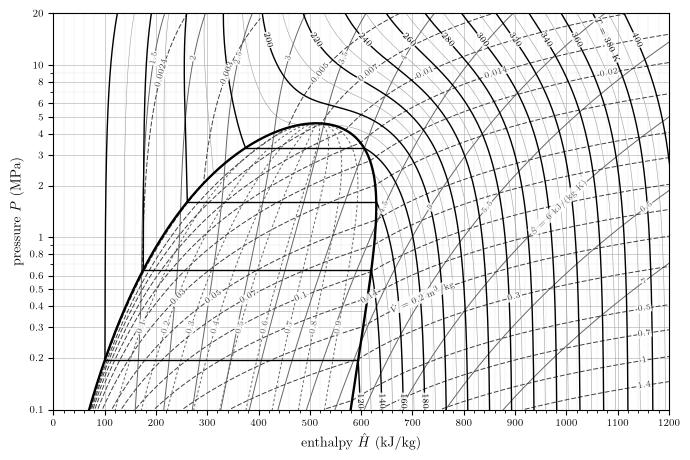

In [7]:
MET = dict(H_lim=(0, 1200), H_grid=100,
           isotherms=range(120, 401, 20), isotherms_minor=range(130, 391, 20),
           isentropes=[x/2 for x in range(3, 15)],
           volumes=(0.0024, 0.003, 0.005, 0.007, 0.01, 0.014, 0.02, 0.03, 0.05,
                    0.07, 0.1, 0.14, 0.2, 0.3, 0.5, 0.7, 1.0, 1.4),
           qualities=[i/10 for i in range(1, 10)],
           T_label_P=14, x_label_P=0.3,
           family_labels=[("T", 380, 14, "$T$ = 380 K"),
                          ("S", 6.0, 1.5, "$\\hat S$ = 6 kJ/(kg K)"),
                          ("V", 0.2, 0.45, "$\\hat V$ = 0.2 m$^3$/kg")])
MET["S_label_P"] = {s: (11 if s <= 4.0 else 1.5) for s in MET["isentropes"]}
MET["V_label_P"] = {v: (9 if v <= 0.02 else 0.45) for v in MET["volumes"]}

methane = ChartFluid("methane", **{k: v for k, v in FLUIDS["methane"].items() if k != "formula"})
fig, ax = plt.subplots(figsize=(7.0, 4.7))     # landscape, about half a page
ph_chart(ax, methane, **MET)
fig.tight_layout()
os.makedirs("pdf", exist_ok=True)
fig.savefig("pdf/Fig_3.3-2.pdf")               # the printed figure
plt.show()

## 6. Figure 3.3-3 &mdash; nitrogen

Same code, same five families, a different three constants and a different heat capacity. The
enthalpy axis is shorter because nitrogen's heat of vaporization is a quarter of methane's, and
the dome is lower because so is its critical point.

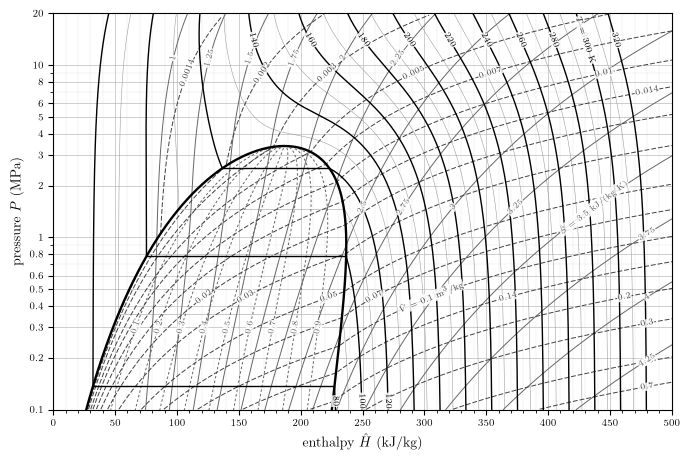

In [8]:
NIT = dict(H_lim=(0, 500), H_grid=50,
           isotherms=range(80, 321, 20), isotherms_minor=range(90, 311, 20),
           isentropes=[x/4 for x in range(4, 18)],
           volumes=(0.0014, 0.002, 0.003, 0.005, 0.007, 0.01, 0.014, 0.02, 0.03,
                    0.05, 0.07, 0.1, 0.14, 0.2, 0.3, 0.5, 0.7),
           qualities=[i/10 for i in range(1, 10)],
           T_label_P=14, x_label_P=0.3,
           family_labels=[("T", 300, 14, "$T$ = 300 K"),
                          ("S", 3.5, 1.5, "$\\hat S$ = 3.5 kJ/(kg K)"),
                          ("V", 0.1, 0.45, "$\\hat V$ = 0.1 m$^3$/kg")])
NIT["S_label_P"] = {s: (11 if s <= 2.25 else 1.5) for s in NIT["isentropes"]}
NIT["V_label_P"] = {v: (9 if v <= 0.014 else 0.45) for v in NIT["volumes"]}

nitrogen = ChartFluid("nitrogen", **{k: v for k, v in FLUIDS["nitrogen"].items() if k != "formula"})
fig, ax = plt.subplots(figsize=(7.0, 4.7))
ph_chart(ax, nitrogen, **NIT)
fig.tight_layout()
fig.savefig("pdf/Fig_3.3-3.pdf")               # the printed figure
plt.show()

## 7. Where these charts are used

Three figures elsewhere in the book are these charts with a process path drawn on them. Each is
built in **its own chapter's notebook**, from the same `thermo.ph_chart` machinery this notebook
uses &mdash; so they move when these charts move, and there is only one copy of the code.

| figure | what it adds | notebook |
|---|---|---|
| **Figure 5.1-3** | Illustration 5.1-1's LNG liquefaction path on the methane chart: three compressor stages, two intercoolers, a final cooler and the Joule&ndash;Thomson expansion | `code/ch5/Linde_liquefaction_CH4_figure.ipynb` |
| **`c06uf002`** | the window of Fig. 3.3-3 that Illustration 6.5-1 reprints, with the cylinder-discharge construction marked | `code/ch6/PR_discharge_N2_example.ipynb` |
| **`c05uf001`** | Illustration 5.2-1's Rankine cycle &mdash; on the *steam* $T$&ndash;$\hat S$ chart, so it comes from `Steam_charts_from_appendix_A3.ipynb`'s machinery instead | `code/ch5/Rankine_cycle_steam_figure.ipynb` |

Each of those notebooks also carries the check that the chart *works* &mdash; Illustration
5.1-1 against the book's own Aspen run, and Illustration 6.5-1 solved five ways. Those checks
belong with the illustration they test.

## What this notebook shows

- Methane's ideal-gas heat capacity is **derivable** from its nine normal modes, and the
  derivation reproduces NIST-JANAF to ±0.03 J/(mol K) &mdash; which is what justifies extending
  it below 298 K, where A.II's printed row is 25 % low and below the physical $4R$ floor.
- Peng&ndash;Robinson earns these charts: vapor pressure within 1.2 % for nitrogen and 4.8 % for
  methane at its coldest corner, which on a logarithmic axis spanning 2.3 decades is under 1 %
  of the plot height.
- **Its one real weakness is saturated-liquid density, about 12 % high.** That lands on
  exactly one family &mdash; the constant-$\hat V$ curves in the compressed-liquid region, left
  of the saturation curve &mdash; which should not be read quantitatively there. The dome, the
  isotherms and the isentropes are unaffected.

## Your turn

- Redraw either chart for a different fluid: `ChartFluid` needs a molar mass, a triple-point
  temperature, and rows in `TABLE_6_6_1` and `APPENDIX_A2_CP_CRYO`. Oxygen and argon are the
  easy next ones.
- Put the two charts in reduced coordinates, $P/P_c$ against $\hat H/\hat H_c$, and see how
  nearly they superimpose. That is the principle of corresponding states, and it is §6.6.